# Bagging ( Bootstraping + Aggregation )

### Loading dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('E:/Dataset/Iris.csv')

In [5]:
df.sample(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
59,60,5.2,2.7,3.9,1.4,Iris-versicolor
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [6]:
df = df.iloc[:, 1:]

In [7]:
df.sample(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
130,7.4,2.8,6.1,1.9,Iris-virginica
45,4.8,3.0,1.4,0.3,Iris-setosa


### Taking 2-D data only

In [17]:
new_df = df[['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [18]:
new_df.sample(2)

,SepalWidthCm,PetalLengthCm,Species
92,2.6,4.0,Iris-versicolor
0,3.5,1.4,Iris-setosa


### Encoding and mixing data

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()

In [19]:
new_df['Species'] = encoder.fit_transform(df['Species'])

C:\Users\Gautam Kumar\AppData\Local\Temp\ipykernel_704\129699780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Species'] = encoder.fit_transform(df['Species'])


In [21]:
new_df = new_df[new_df['Species'] != 0]

In [22]:
new_df.shape

(100, 3)

In [23]:
new_df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [26]:
new_df = new_df.sample(100)

In [28]:
new_df.head()

,SepalWidthCm,PetalLengthCm,Species
123,2.7,4.9,2
74,2.9,4.3,1
106,2.5,4.5,2
84,3.0,4.5,1
113,2.5,5.0,2


## Bagging starts

### Dividing data into train, test, validation

In [71]:
df_train = new_df.iloc[:60, :].sample(12)
df_test = new_df.iloc[60:80, :].sample(7)
df_val = new_df.iloc[80:, :].sample(5)

In [72]:
df_train

,SepalWidthCm,PetalLengthCm,Species
149,3.0,5.1,2
62,2.2,4.0,1
86,3.1,4.7,1
71,2.8,4.0,1
72,2.5,4.9,1
99,2.8,4.1,1
129,3.0,5.8,2
106,2.5,4.5,2
128,2.8,5.6,2
115,3.2,5.3,2


In [73]:
df_test

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
88,3.0,4.1,1
125,3.2,6.0,2
135,3.0,6.1,2
133,2.8,5.1,2
139,3.1,5.4,2
75,3.0,4.4,1


In [74]:
df_val

,SepalWidthCm,PetalLengthCm,Species
56,3.3,4.7,1
119,2.2,5.0,2
83,2.7,5.1,1
112,3.0,5.5,2
138,3.0,4.8,2


### Splitting test data into i/p and o/p

In [75]:
x_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

In [76]:
x_test

array([[2.5, 3.9],
       [3. , 4.1],
       [3.2, 6. ],
       [3. , 6.1],
       [2.8, 5.1],
       [3.1, 5.4],
       [3. , 4.4]])

In [77]:
y_test

array([1, 1, 2, 2, 2, 2, 1])

### Importing required classes

In [43]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [48]:
import matplotlib.pyplot as plt

### Function for training, finding accuracy, and plotting tree & decision boundary

In [78]:
def evaluate(model, x, y):
    model.fit(x, y)
    plt.figure(figsize=(3,3))
    plot_tree(model)
    plt.tight_layout()
    plt.show()
    y_pred = model.predict(x_test)
    print(f"Accuracy = {accuracy_score(y_test, y_pred)}")
    plt.figure(figsize=(5,4))
    plot_decision_regions(x.values, y.values, clf=model, legend=2)

### Trainiing first model on first sample of data

In [79]:
# Data for 1st tree
df_bag1 = df_train.sample(8, replace=True)  # Replace=True means repetation of data allows
x1 = df_bag1.iloc[:, :-1]
y1 = df_bag1.iloc[:, -1]

df_bag1

,SepalWidthCm,PetalLengthCm,Species
117,3.8,6.7,2
149,3.0,5.1,2
128,2.8,5.6,2
128,2.8,5.6,2
71,2.8,4.0,1
128,2.8,5.6,2
115,3.2,5.3,2
71,2.8,4.0,1


In [80]:
dt_reg1 = DecisionTreeClassifier()

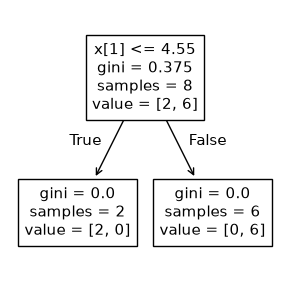

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy = 1.0


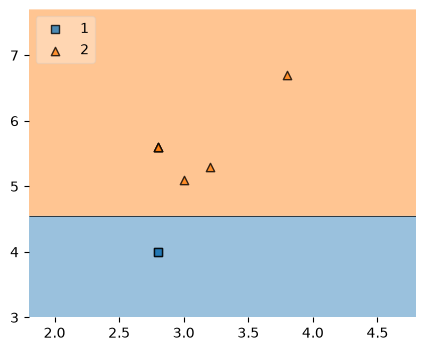

In [81]:
evaluate(dt_reg1, x1, y1)

### Trainiing second model on second sample of data

In [96]:
# Data for 2nd tree
df_bag2 = df_train.sample(8, replace=True)  # Replace=True means repetation of data allows
x2 = df_bag2.iloc[:, :-1]
y2 = df_bag2.iloc[:, -1]

df_bag2

,SepalWidthCm,PetalLengthCm,Species
117,3.8,6.7,2
99,2.8,4.1,1
115,3.2,5.3,2
72,2.5,4.9,1
106,2.5,4.5,2
128,2.8,5.6,2
62,2.2,4.0,1
128,2.8,5.6,2


In [83]:
dt_reg2 = DecisionTreeClassifier()

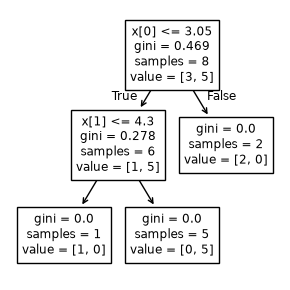

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy = 0.5714285714285714


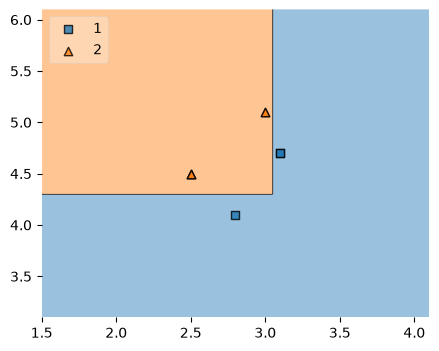

In [84]:
evaluate(dt_reg2, x2, y2)

### Trainiing third model on third sample of data

In [97]:
# Data for 3rd tree
df_bag3 = df_train.sample(8, replace=True)  # Replace=True means repetation of data allows
x3 = df_bag3.iloc[:, :-1]
y3 = df_bag3.iloc[:, -1]

df_bag3

,SepalWidthCm,PetalLengthCm,Species
99,2.8,4.1,1
117,3.8,6.7,2
62,2.2,4.0,1
107,2.9,6.3,2
72,2.5,4.9,1
115,3.2,5.3,2
115,3.2,5.3,2
115,3.2,5.3,2


In [86]:
dt_reg3 = DecisionTreeClassifier()

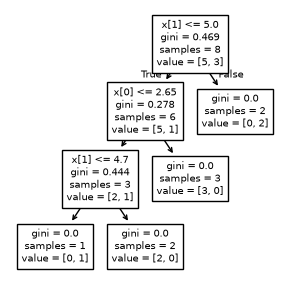

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy = 0.8571428571428571


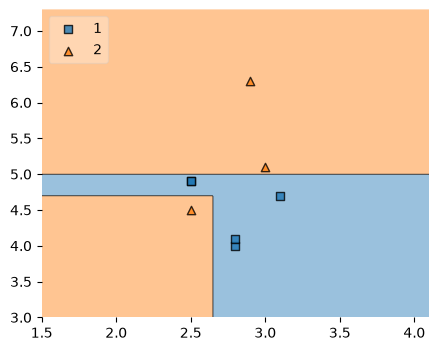

In [87]:
evaluate(dt_reg3, x3, y3)

### Validating our model on new data

In [88]:
df_val

,SepalWidthCm,PetalLengthCm,Species
56,3.3,4.7,1
119,2.2,5.0,2
83,2.7,5.1,1
112,3.0,5.5,2
138,3.0,4.8,2


In [95]:
print(f"Predictor 1 - {dt_reg1.predict(np.array([2.2, 5]).reshape(1,2))}")
print(f"Predictor 2 - {dt_reg2.predict(np.array([2.2, 5]).reshape(1,2))}")
print(f"Predictor 3 - {dt_reg3.predict(np.array([2.2, 5]).reshape(1,2))}")

Predictor 1 - [2]
Predictor 2 - [2]
Predictor 3 - [1]


E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Types of Bagging

### i) Pasting ( Row sampling without replacement **(replace=False)** )

In [98]:
df_train

,SepalWidthCm,PetalLengthCm,Species
149,3.0,5.1,2
62,2.2,4.0,1
86,3.1,4.7,1
71,2.8,4.0,1
72,2.5,4.9,1
99,2.8,4.1,1
129,3.0,5.8,2
106,2.5,4.5,2
128,2.8,5.6,2
115,3.2,5.3,2


In [102]:
df_train.sample(6)

,SepalWidthCm,PetalLengthCm,Species
106,2.5,4.5,2
128,2.8,5.6,2
71,2.8,4.0,1
99,2.8,4.1,1
107,2.9,6.3,2
72,2.5,4.9,1


### ii) Random subspaces ( Column sampling )

In [104]:
df.sample(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
128,6.4,2.8,5.6,2.1,Iris-virginica
91,6.1,3.0,4.6,1.4,Iris-versicolor
13,4.3,3.0,1.1,0.1,Iris-setosa


In [105]:
df.shape

(150, 5)

In [114]:
df.sample(2, axis=1, replace=False, random_state=22)  # axis=1 means column sampling

,SepalWidthCm,PetalLengthCm
0,3.5,1.4
1,3.0,1.4
2,3.2,1.3
3,3.1,1.5
4,3.6,1.4
...,...,...
145,3.0,5.2
146,2.5,5.0
147,3.0,5.2
148,3.4,5.4


### iii) Random Patches ( Row and column both sampling )

In [115]:
df.sample(2, axis=1, replace=False).sample(8, replace=True)

,SepalLengthCm,PetalWidthCm
70,5.9,1.8
21,5.1,0.4
95,5.7,1.2
145,6.7,2.3
56,6.3,1.6
101,5.8,1.9
95,5.7,1.2
58,6.6,1.3
